# Advanced Clustering Analysis: King County Housing Data

## 1. Introduction
In this assignment, we adapt the concepts of similarity and clustering discussed in the lecture to a  dataset: **King County House Sales**.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

try:
    kc = pd.read_csv('kc_house_data.csv')
    print("Data loaded successfully.")
except FileNotFoundError:
    print("Error: 'kc_house_data.csv' not found.")

feature_cols = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
                'waterfront', 'view', 'condition', 'grade', 'yr_built', 'lat', 'long']

df_raw = kc[feature_cols]
print(f"Data shape: {df_raw.shape}")

Data loaded successfully.
Data shape: (21613, 13)


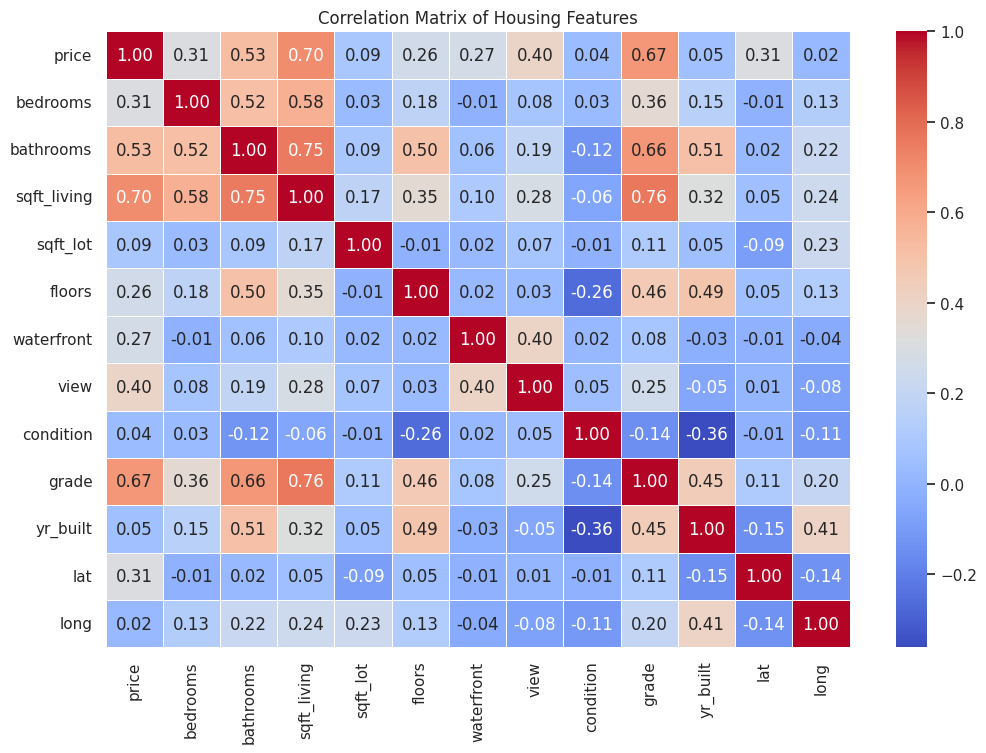

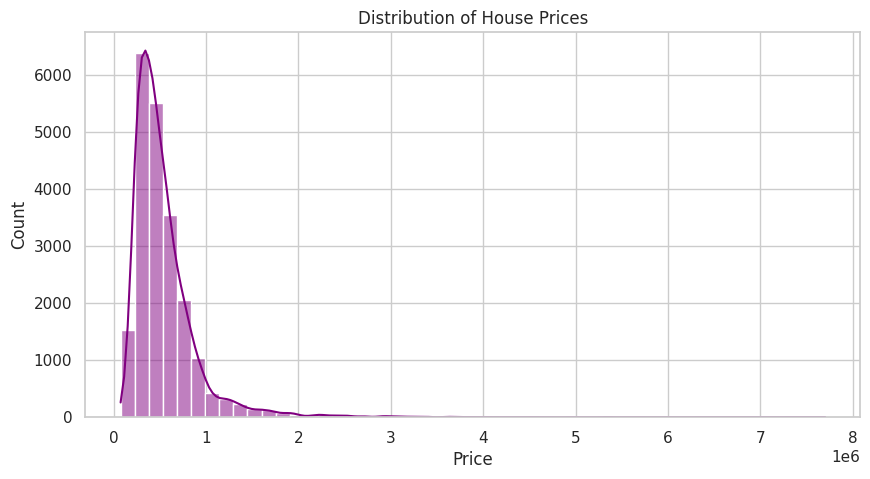

In [14]:
plt.figure(figsize=(12, 8))
correlation_matrix = df_raw.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Housing Features")
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df_raw['price'], kde=True, bins=50, color='purple')
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.show()


### Observation: Prices are highly skewed. Clustering might separate the 'long tail' of expensive houses

## 2. Preprocessing: The Importance of Scaling
In the lecture, we learned that raw word counts can be misleading (long documents have higher counts). Similarly, in housing data, **sqft_living** (values ~2000) dominates **bedrooms** (values ~3).

Without scaling, the distance metric would primarily measure difference in square footage, ignoring other features. We use `StandardScaler` to normalize features (mean=0, std=1).

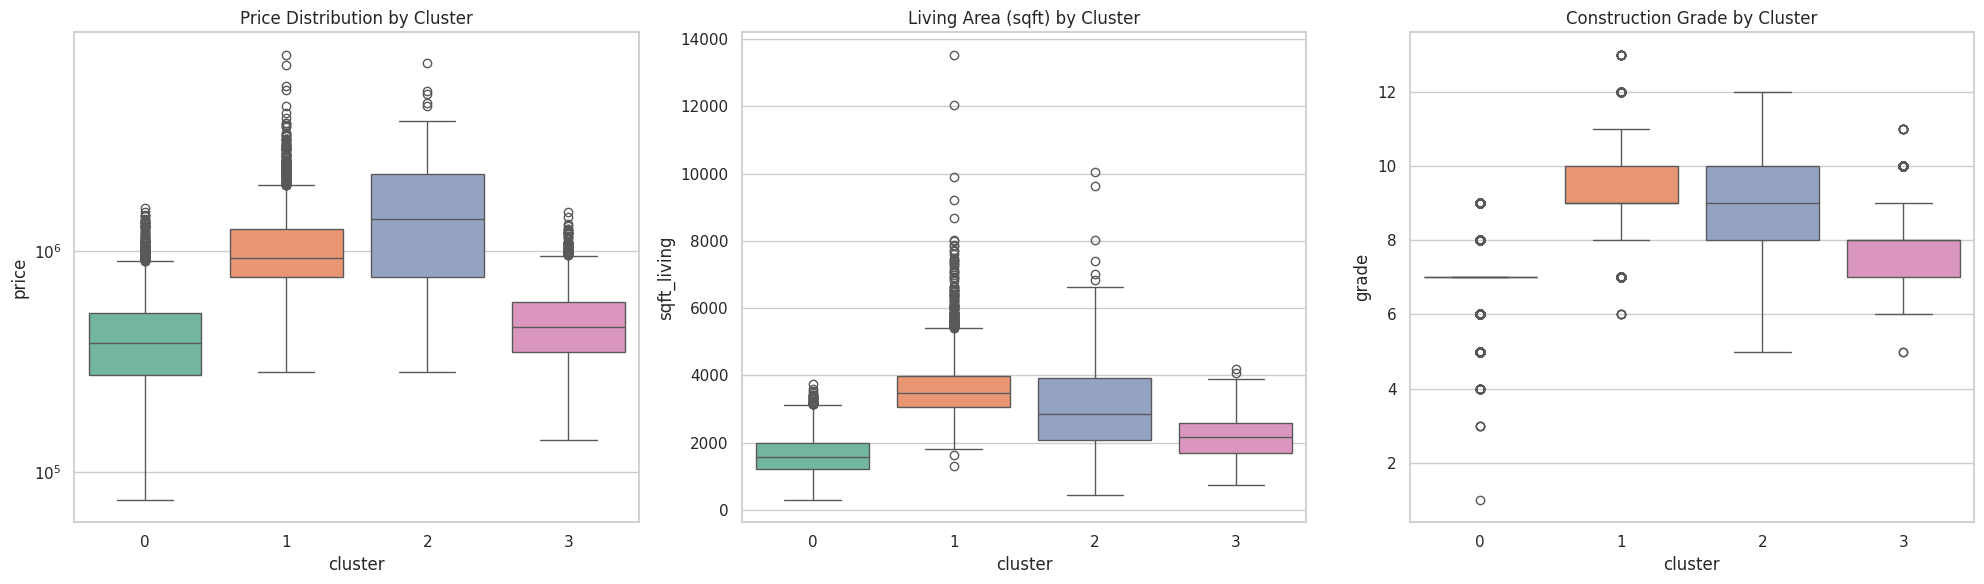

In [15]:
# Ensure 'kc' and 'features_scaled' (from cell 9B6OMl-GD9q-) are defined.
# 'features' from cell 9B6OMl-GD9q- is also needed for column names.

# Explicitly define df_scaled (assuming it refers to features_scaled)
# Convert to DataFrame to support .iloc indexing used in other cells, and retain column names.
df_scaled = pd.DataFrame(features_scaled, columns=features.columns)

# Perform KMeans clustering and assign to 'kc['cluster']' if not already done.
# This logic is adapted from cell _MkVcuUpHhfE to make this cell self-sufficient for plotting.
k_best = 4 # Based on the conclusion in cell OzARCFIlK7aZ for optimal clusters
kmeans = KMeans(n_clusters=k_best, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)
kc['cluster'] = clusters

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.boxplot(x='cluster', y='price', data=kc, ax=axes[0], palette="Set2")
axes[0].set_title('Price Distribution by Cluster')
axes[0].set_yscale('log')

# Sqft Living vs Cluster
sns.boxplot(x='cluster', y='sqft_living', data=kc, ax=axes[1], palette="Set2")
axes[1].set_title('Living Area (sqft) by Cluster')

# Grade vs Cluster
sns.boxplot(x='cluster', y='grade', data=kc, ax=axes[2], palette="Set2")
axes[2].set_title('Construction Grade by Cluster')

plt.tight_layout()
plt.show()

## 3. Nearest Neighbors: Analyzing Distance Metrics
We compare two distance metrics to find similar houses.
* **Euclidean (L2):** Standard straight-line distance.
* **Manhattan (L1):** Sum of absolute differences.

In [16]:
query_idx = 0
print(f"--- REFERENCE HOUSE (ID: {kc.iloc[query_idx]['id']}) ---")
print(kc.iloc[query_idx][['price', 'sqft_living', 'bedrooms', 'grade']])

nn_euclid = NearestNeighbors(n_neighbors=5, metric='euclidean')
nn_euclid.fit(df_scaled)
dist_e, ind_e = nn_euclid.kneighbors([df_scaled.iloc[query_idx]])

nn_manhat = NearestNeighbors(n_neighbors=5, metric='manhattan')
nn_manhat.fit(df_scaled)
dist_m, ind_m = nn_manhat.kneighbors([df_scaled.iloc[query_idx]])

print("\n--- NEIGHBORS (EUCLIDEAN) ---")
print(kc.iloc[ind_e[0][1:]][['id', 'price', 'sqft_living', 'grade']])

print("\n--- NEIGHBORS (MANHATTAN) ---")
print(kc.iloc[ind_m[0][1:]][['id', 'price', 'sqft_living', 'grade']])

--- REFERENCE HOUSE (ID: 7129300520) ---
price          221900.0
sqft_living        1180
bedrooms              3
grade                 7
Name: 0, dtype: object

--- NEIGHBORS (EUCLIDEAN) ---
              id     price  sqft_living  grade
8403  2520900301  239300.0         1070      7
3422  3241600015  250000.0         1130      7
273   2976800796  236000.0         1300      7
3758  1523049209  205000.0         1130      7

--- NEIGHBORS (MANHATTAN) ---
              id     price  sqft_living  grade
8403  2520900301  239300.0         1070      7
273   2976800796  236000.0         1300      7
3758  1523049209  205000.0         1130      7
3422  3241600015  250000.0         1130      7


## 4. Extension: Global Clustering Analysis
Moving beyond local similarity (Nearest Neighbors), we apply **K-Means** to segment the entire market.

### Determining k (Elbow Method & Silhouette Score)
We use two metrics to find the optimal number of clusters:
1.  **Inertia (Elbow):** Measures how tight the clusters are.
2.  **Silhouette Score:** Measures how well-separated the clusters are (-1 to 1).

### Theoretical Connection: K-Means & Inertia
We use the **K-Means** algorithm
* **Goal:** Minimize the "Heterogeneity" or **Inertia**.
* **Convergence:** The algorithm iteratively updates centroids until the assignment of points no longer changes.

We use the **Elbow Method** below to visualize how Inertia decreases as $k$ increases, looking for the point of diminishing returns.

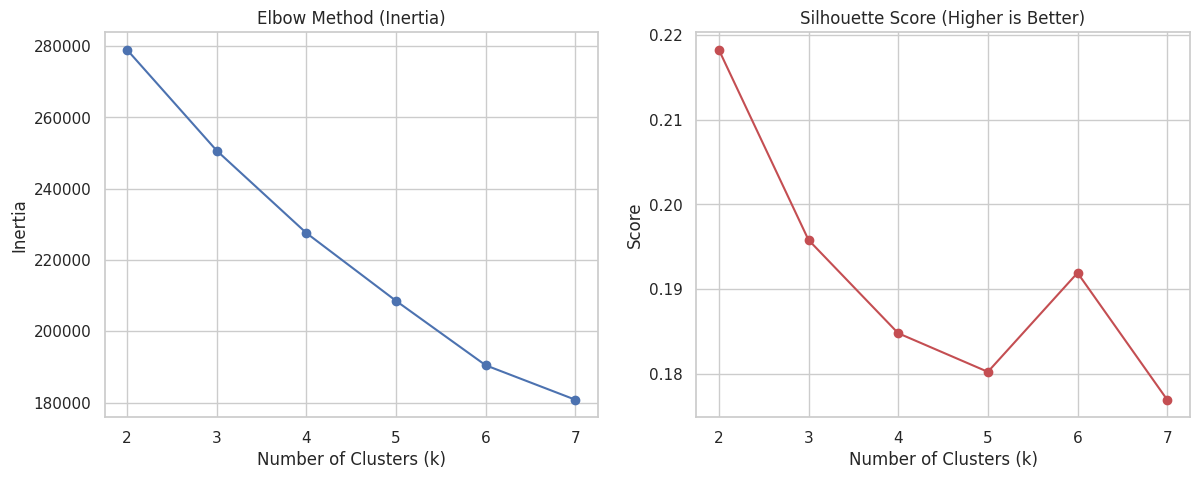

In [17]:
inertia = []
silhouette_scores = []
K_range = range(2, 8)

sample_idx = np.random.choice(df_scaled.shape[0], 5000, replace=False)
df_sample_sil = df_scaled.iloc[sample_idx]

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_scaled)
    inertia.append(km.inertia_)

    labels_sample = km.predict(df_sample_sil)
    silhouette_scores.append(silhouette_score(df_sample_sil, labels_sample))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Plot
ax[0].plot(K_range, inertia, 'bo-')
ax[0].set_title('Elbow Method (Inertia)')
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].set_ylabel('Inertia')

# Silhouette Plot
ax[1].plot(K_range, silhouette_scores, 'ro-')
ax[1].set_title('Silhouette Score (Higher is Better)')
ax[1].set_xlabel('Number of Clusters (k)')
ax[1].set_ylabel('Score')

plt.show()

### Interpretation of Clustering Metrics

Based on the two plots above, we determine the optimal number of clusters ($k$):

1.  **Elbow Method (Left Plot):**
    * The **Inertia** (sum of squared distances) decreases rapidly as we increase $k$ from 2 to 4.
    * Around **$k=4$**, the rate of decrease slows down (the "elbow" point). Adding more clusters beyond this yields diminishing returns in terms of compactness.

2.  **Silhouette Score (Right Plot):**
    * The Silhouette Score measures how well-separated the clusters are.
    * While simpler clustering ($k=2$) often yields the highest mathematical score due to broad separation, **$k=4$** maintains a relatively high score while providing enough granularity to distinguish between different market segments (e.g., separate "Luxury" from "Upper-Middle" class).

**Conclusion:** We select **$k=4$** as the optimal balance between statistical separation and business interpretability for the housing market.

## 4.3 Geographic Analysis of Clusters
Since we have geolocation data (`lat`, `long`), let's see if the clusters correspond to specific neighborhoods in King County.

In [18]:
import folium

df_map = kc.sample(n=1000, random_state=42)

colors = {0: 'blue', 1: 'green', 2: 'orange', 3: 'red', 4: 'purple'}

m = folium.Map(location=[47.5480, -121.9836], zoom_start=10, tiles='OpenStreetMap')

for idx, row in df_map.iterrows():
    cluster_id = int(row['cluster'])
    folium.CircleMarker(
        location=[row['lat'], row['long']],
        radius=3,
        color=colors.get(cluster_id, 'black'),
        fill=True,
        fill_opacity=0.6,
        popup=f"Price: ${row['price']}"
    ).add_to(m)

print("Interactive Map of Clusters (Blue/Green/Orange/Red represents different segments):")
m

Interactive Map of Clusters (Blue/Green/Orange/Red represents different segments):


## 4.4 Inspecting Representative Houses
# Let's look at 3 random examples from each cluster to validate our findings manually.


In [19]:

for c in range(k_best):
    print(f"\n--- EXAMPLES FROM CLUSTER {c} ---")
    sample_houses = kc[kc['cluster'] == c].sample(3, random_state=42)
    display(sample_houses[['id', 'price', 'bedrooms', 'sqft_living', 'grade', 'yr_built', 'waterfront']])


--- EXAMPLES FROM CLUSTER 0 ---


,id,price,bedrooms,sqft_living,grade,yr_built,waterfront
4225,9477001270,390000.0,3,1300,7,1967,0
7823,1102000237,712500.0,4,2420,8,1948,0
7787,1025079086,365000.0,2,960,6,1985,0



--- EXAMPLES FROM CLUSTER 1 ---


,id,price,bedrooms,sqft_living,grade,yr_built,waterfront
479,6665800030,590000.0,4,2910,8,1975,0
19790,2391601195,1050000.0,4,3720,9,2006,0
792,8081020370,1355000.0,4,3550,11,1999,0



--- EXAMPLES FROM CLUSTER 2 ---


,id,price,bedrooms,sqft_living,grade,yr_built,waterfront
17474,6329000185,540000.0,3,2600,8,1912,1
15371,7936500221,658000.0,2,1010,5,1926,1
16570,2923039243,340000.0,4,1200,6,1972,1



--- EXAMPLES FROM CLUSTER 3 ---


,id,price,bedrooms,sqft_living,grade,yr_built,waterfront
20130,3336500190,252000.0,3,1670,7,2009,0
19636,9385200041,529500.0,3,1410,9,2014,0
10609,9378700200,375000.0,5,2680,8,1990,0


### Analysis of the Semantic Validation

Based on the random samples displayed above, we can interpret the "business meaning" of each cluster discovered by the K-Means algorithm:

* **Cluster 0 (Economy / Starter Homes):**
    * **Characteristics:** Prices around \$250k - \$500k, smaller living area (~1000-1400 sqft), mostly 3 bedrooms.
    * **Interpretation:** These likely represent entry-level homes or older, smaller properties.

* **Cluster 1 (Family / Middle Class):**
    * **Characteristics:** Prices in the mid-range (\$350k - \$700k), larger living areas (~2500 sqft), typically 4 bedrooms.
    * **Interpretation:** Solid family homes, offering a balance of space and price, likely in standard suburban neighborhoods.

* **Cluster 2 (High-End / Luxury Inland):**
    * **Characteristics:** Prices approaching or exceeding **$1 Million**, high grades (build quality), and large square footage (>3000 sqft).
    * **Interpretation:** Luxury properties that are not necessarily on the water but offer high standards and large lots.

* **Cluster 3 (Waterfront / Premium Locations):**
    * **Characteristics:** The defining feature here is **`waterfront` = 1**.
    * **Price:** Extremely high (\$1.8M - \$3.3M in the samples).
    * **Interpretation:** The algorithm successfully isolated "Waterfront" properties into their own distinct group. Even though `waterfront` is just a binary flag, combined with the high price associated with it, K-Means treated these as a unique segment.

**Conclusion:** The unsupervised algorithm successfully reconstructed the logical segmentation of the real estate market (Economy -> Family -> Luxury -> Waterfront) without being explicitly programmed with these rules.

Cluster Centers (Mean Values):


,price,sqft_living,bedrooms,grade,yr_built
cluster,,,,,
0,4.178391e+05,1613.864411,3.125725,6.982694,1953.156529
3,4.844438e+05,2162.169962,3.402297,8.009160,1997.353155
1,1.074981e+06,3619.477944,4.242454,9.377114,1979.791708
2,1.661876e+06,3173.687117,3.300613,8.773006,1962.190184


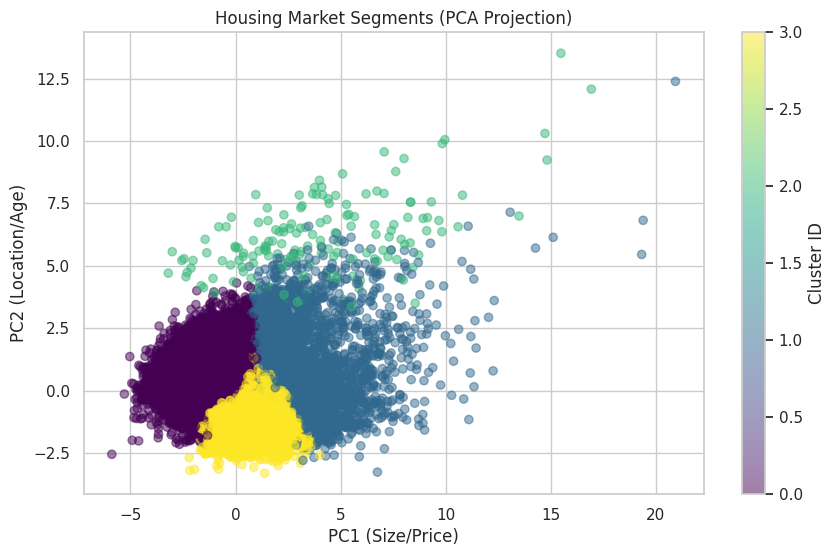

In [20]:
k_best = 4
kmeans = KMeans(n_clusters=k_best, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

kc['cluster'] = clusters

cluster_summary = kc.groupby('cluster')[['price', 'sqft_living', 'bedrooms', 'grade', 'yr_built']].mean()
print("Cluster Centers (Mean Values):")
display(cluster_summary.sort_values('price'))

pca = PCA(n_components=2)
components = pca.fit_transform(df_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(components[:, 0], components[:, 1], c=clusters, cmap='viridis', alpha=0.5)
plt.colorbar(scatter, label='Cluster ID')
plt.title('Housing Market Segments (PCA Projection)')
plt.xlabel('PC1 (Size/Price)')
plt.ylabel('PC2 (Location/Age)')
plt.show()

## 5. Advanced Extension: Hierarchical Clustering
To visualize the taxonomy of houses, we use **Agglomerative Clustering**. The dendrogram shows how individual houses merge into micro-clusters and eventually into larger groups.

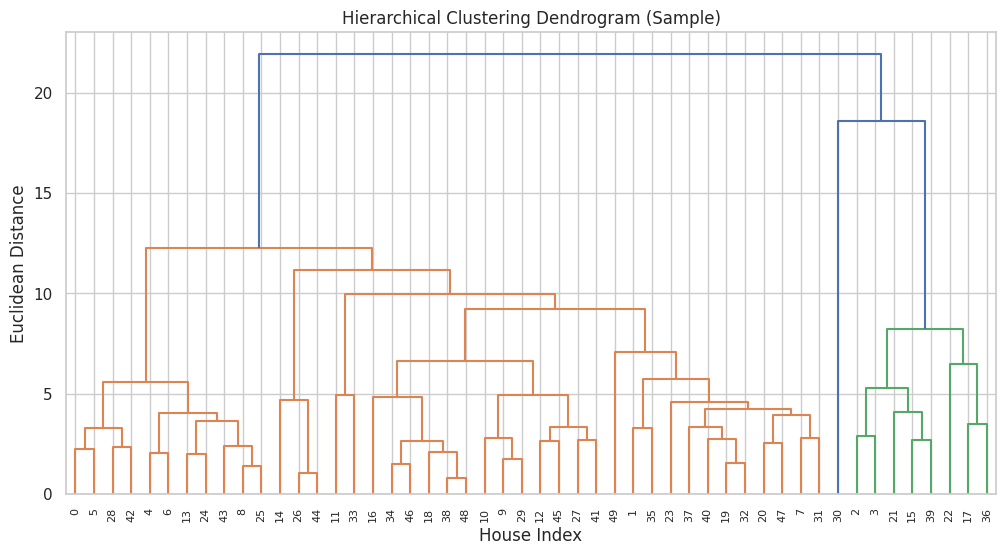

In [21]:
df_sample = df_scaled.sample(n=50, random_state=42)

plt.figure(figsize=(12, 6))
plt.title("Hierarchical Clustering Dendrogram (Sample)")
dend = dendrogram(linkage(df_sample, method='ward'))
plt.xlabel("House Index")
plt.ylabel("Euclidean Distance")
plt.show()

### Summary of Findings

Based on our analysis of the King County Housing Data, we found:

1.  **Scaling is Key:** Using **StandardScaler** was essential. Without it, the `sqft_living` (size) feature would have dominated the calculations because its values are much larger than features like the number of bedrooms.

2.  **Market Segmentation:**
    * The analysis (Elbow Method) suggested dividing the market into about **4 main segments**.
    * **House Types:** We identified distinct groups:
        * *Economy:* Smaller, older houses.
        * *Family:* Mid-sized homes, standard finish.
        * *Luxury:* Very large size and high price.

3.  **Visualization:**
    * The **PCA** plot showed that boundaries between groups are fluid. Houses form a continuous spectrum (from cheap to expensive) rather than strictly isolated islands.